In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
    
    
RESULTS_FILE_PATH = PROJECT_ROOT / 'reports' / 'official_test_predictions.csv'

print(f'Project root path is: {PROJECT_ROOT}')
print(f'Results file exists: {RESULTS_FILE_PATH.exists()}')

Project root path is: c:\Users\VENKATESH\aircraft-rul-predictor
Results file exists: True


In [3]:
results_df = pd.read_csv(RESULTS_FILE_PATH)

print(f'Results shape: {results_df.shape}')

results_df.head()

Results shape: (100, 5)


,unit_number,true_rul,predicted_rul,absolute_error,prediction_error
0,27,66,115.046684,49.046684,-49.046684
1,79,63,111.809640,48.809639,-48.809639
2,41,18,65.267550,47.267548,-47.267548
3,45,114,68.590890,45.409111,45.409111
4,93,85,41.830050,43.169949,43.169949


In [4]:
results_df.tail(10)

,unit_number,true_rul,predicted_rul,absolute_error,prediction_error
90,81,8,6.298977,1.701023,1.701023
91,40,28,26.376540,1.623461,1.623461
92,51,114,115.250510,1.250511,-1.250511
93,66,14,14.939158,0.939158,-0.939158
94,56,15,15.752387,0.752387,-0.752387
95,82,9,8.495389,0.504611,0.504611
96,46,47,47.464690,0.464691,-0.464691
97,52,29,29.233185,0.233185,-0.233185
98,77,34,34.156860,0.156860,-0.156860
99,34,7,7.094961,0.094961,-0.094961


In [5]:
error_summary = results_df[['absolute_error', 'prediction_error']].describe()

error_summary

,absolute_error,prediction_error
count,100.000000,100.000000
mean,13.144955,-1.690527
std,12.237780,17.927959
min,0.094961,-49.046684
25%,4.067025,-10.305901
50%,8.660152,-1.094835
75%,19.205732,6.865887
max,49.046684,45.409111


In [6]:
over_predictions = (results_df['prediction_error'] < 0).sum()
under_predictions = (results_df['prediction_error'] > 0).sum()
perfect_predictions = (results_df['prediction_error'] == 0).sum()

print("Overpredictions:", over_predictions)
print("Underpredictions:", under_predictions)
print("Perfect predictions:", perfect_predictions)

print("\nOverprediction percentage:", round(over_predictions / len(results_df) * 100, 2), "%")
print("Underprediction percentage:", round(under_predictions / len(results_df) * 100, 2), "%")

Overpredictions: 56
Underpredictions: 44
Perfect predictions: 0

Overprediction percentage: 56.0 %
Underprediction percentage: 44.0 %


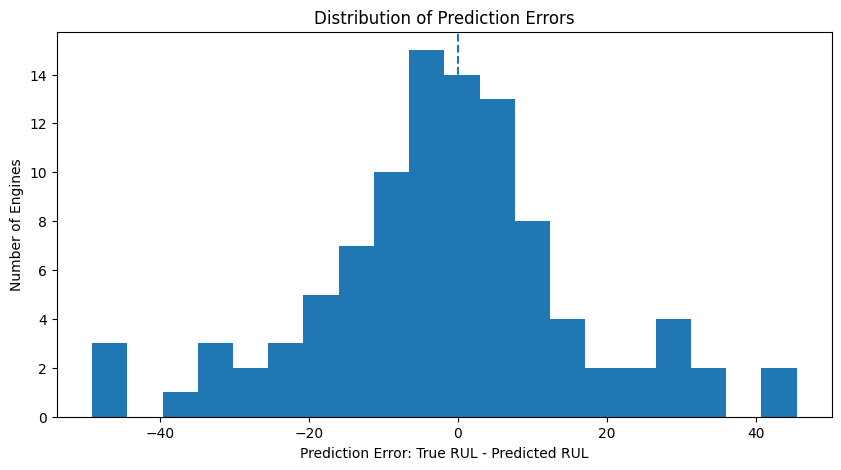

In [7]:
plt.figure(figsize=(10, 5))

plt.hist(
    results_df["prediction_error"],
    bins=20,
)

plt.axvline(
    x=0,
    linestyle="--",
)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error: True RUL - Predicted RUL")
plt.ylabel("Number of Engines")
plt.show()

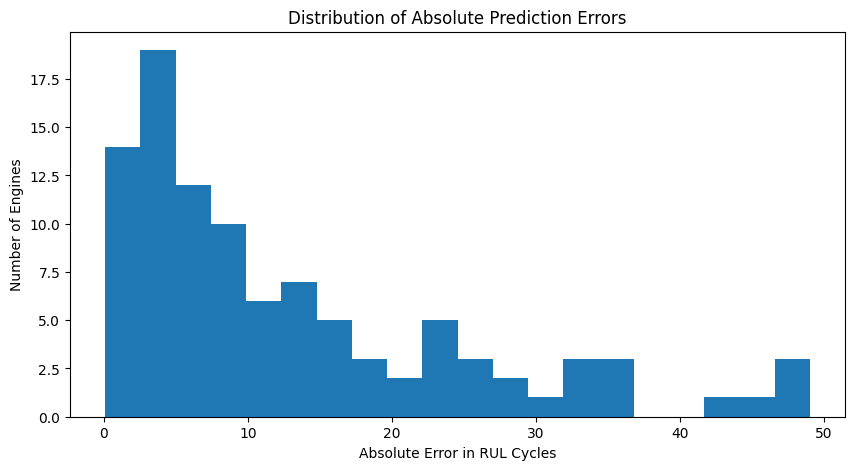

In [8]:
plt.figure(figsize=(10, 5))

plt.hist(
    results_df["absolute_error"],
    bins=20,
)

plt.title("Distribution of Absolute Prediction Errors")
plt.xlabel("Absolute Error in RUL Cycles")
plt.ylabel("Number of Engines")
plt.show()

In [9]:
worst_predictions = results_df.sort_values(
    by = 'absolute_error',
    ascending = False,
    
).head(10)

worst_predictions

,unit_number,true_rul,predicted_rul,absolute_error,prediction_error
0,27,66,115.046684,49.046684,-49.046684
1,79,63,111.809640,48.809639,-48.809639
2,41,18,65.267550,47.267548,-47.267548
3,45,114,68.590890,45.409111,45.409111
4,93,85,41.830050,43.169949,43.169949
5,15,83,119.774580,36.774582,-36.774582
6,12,124,89.083405,34.916595,34.916595
7,37,21,55.691370,34.691368,-34.691368
8,67,77,110.926056,33.926056,-33.926056
9,11,97,64.931350,32.068649,32.068649


In [11]:
best_predictions = results_df.sort_values(
    by = 'absolute_error',
    ascending = True,
).head(10)

best_predictions 

,unit_number,true_rul,predicted_rul,absolute_error,prediction_error
99,34,7,7.094961,0.094961,-0.094961
98,77,34,34.156860,0.156860,-0.156860
97,52,29,29.233185,0.233185,-0.233185
96,46,47,47.464690,0.464691,-0.464691
95,82,9,8.495389,0.504611,0.504611
94,56,15,15.752387,0.752387,-0.752387
93,66,14,14.939158,0.939158,-0.939158
92,51,114,115.250510,1.250511,-1.250511
91,40,28,26.376540,1.623461,1.623461
90,81,8,6.298977,1.701023,1.701023


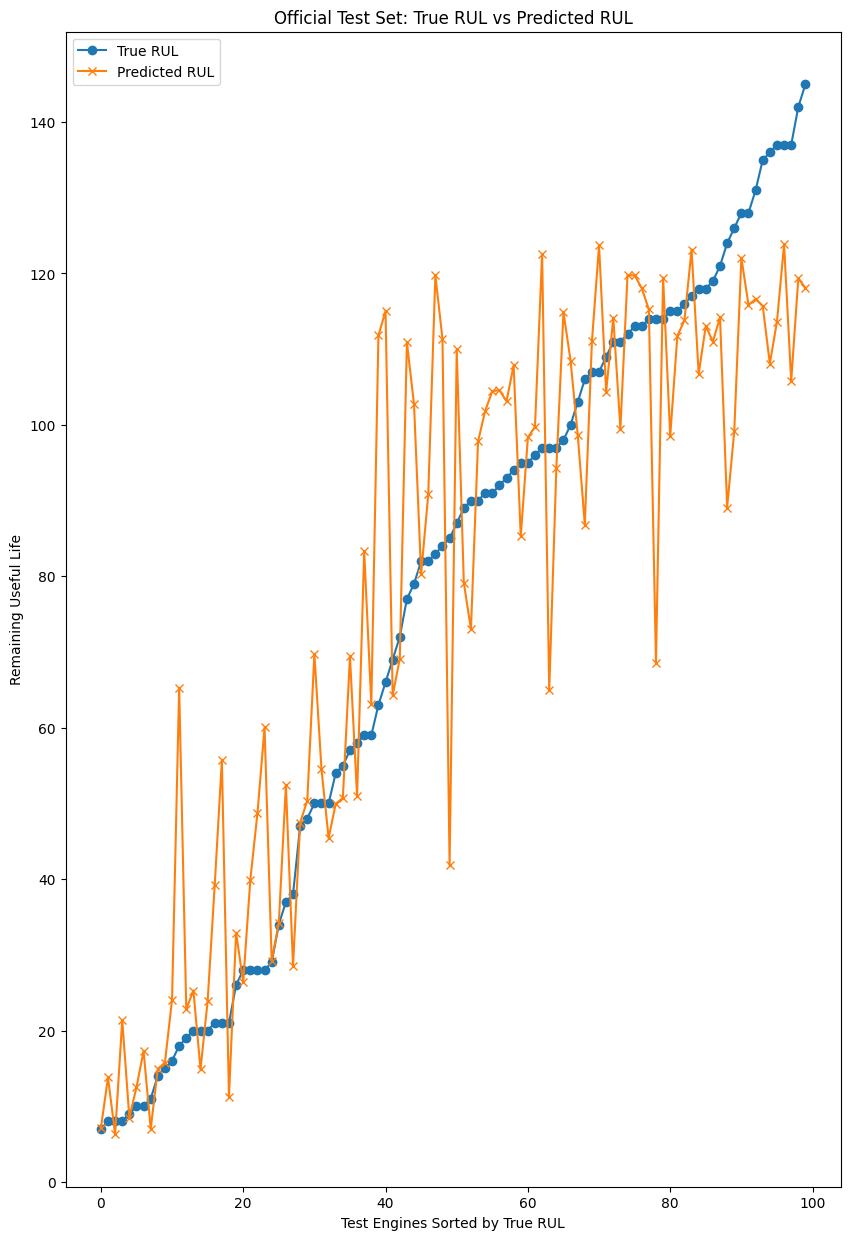

In [12]:
results_sorted = results_df.sort_values(by = 'true_rul').reset_index(drop = True)

plt.figure(figsize = (10,15))

plt.plot(
    results_sorted['true_rul'],
    label = 'True RUL',
    marker = 'o',
)

plt.plot(
    results_sorted['predicted_rul'],
    label = 'Predicted RUL',
    marker = 'x',
)

plt.title("Official Test Set: True RUL vs Predicted RUL")
plt.xlabel("Test Engines Sorted by True RUL")
plt.ylabel("Remaining Useful Life")
plt.legend()
plt.show()

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np

BUSINESS_RUL_CAP = 125

results_df['true_rul_capped'] = results_df['true_rul'].clip(upper = BUSINESS_RUL_CAP)

capped_mae = mean_absolute_error(
    results_df['true_rul_capped'],
    results_df['predicted_rul'],
)

capped_rmse = np.sqrt(
    mean_squared_error(
        results_df['true_rul_capped'],
        results_df['predicted_rul'],
    )
)


capped_r2 = r2_score(results_df['true_rul_capped'],
    results_df['predicted_rul'],)

print("Capped Official Test Performance")
print("--------------------------------")
print("MAE:", round(capped_mae, 2))
print("RMSE:", round(capped_rmse, 2))
print("R2 Score:", round(capped_r2, 4))

Capped Official Test Performance
--------------------------------
MAE: 12.07
RMSE: 16.94
R2 Score: 0.8213


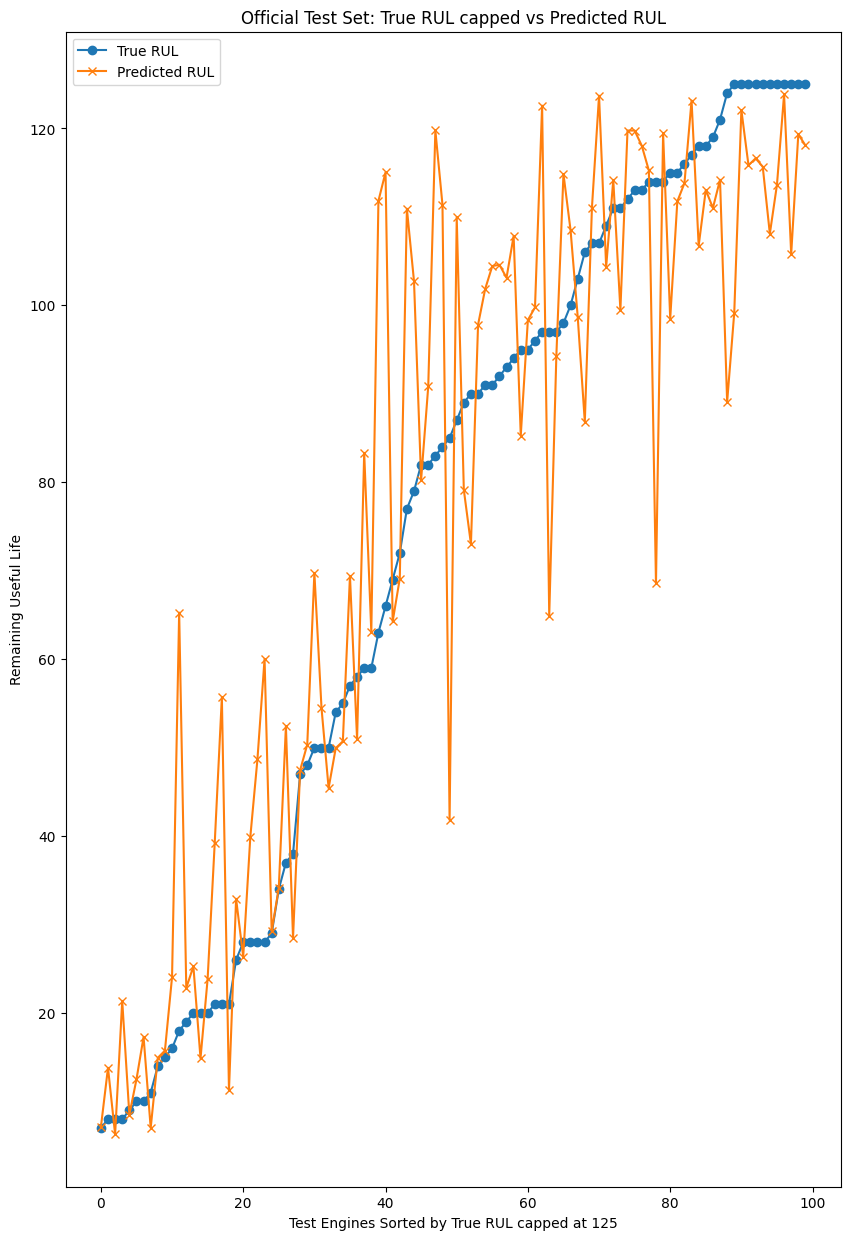

In [17]:
results_sorted = results_df.sort_values(by = 'true_rul').reset_index(drop = True)

plt.figure(figsize = (10,15))

plt.plot(
    results_sorted['true_rul_capped'],
    label = 'True RUL',
    marker = 'o',
)

plt.plot(
    results_sorted['predicted_rul'],
    label = 'Predicted RUL',
    marker = 'x',
)

plt.title("Official Test Set: True RUL capped vs Predicted RUL")
plt.xlabel("Test Engines Sorted by True RUL capped at 125")
plt.ylabel("Remaining Useful Life")
plt.legend()
plt.show()

In [18]:
danger_zone_df = results_df[results_df["true_rul"] <= 30].copy()

danger_zone_mae = danger_zone_df["absolute_error"].mean()
danger_zone_median_error = danger_zone_df["absolute_error"].median()
danger_zone_count = len(danger_zone_df)

print("Danger Zone Performance: True RUL <= 30")
print("---------------------------------------")
print("Number of engines:", danger_zone_count)
print("Mean absolute error:", round(danger_zone_mae, 2))
print("Median absolute error:", round(danger_zone_median_error, 2))

danger_zone_df.sort_values(by="absolute_error", ascending=False)

Danger Zone Performance: True RUL <= 30
---------------------------------------
Number of engines: 25
Mean absolute error: 9.86
Median absolute error: 5.28


,unit_number,true_rul,predicted_rul,absolute_error,prediction_error,true_rul_capped
2,41,18,65.267550,47.267548,-47.267548,18
7,37,21,55.691370,34.691368,-34.691368,21
10,18,28,60.037083,32.037083,-32.037083,28
22,64,28,48.690430,20.690430,-20.690430,28
26,61,21,39.269430,18.269428,-18.269428,21
35,31,8,21.372684,13.372684,-13.372684,8
40,90,28,39.921135,11.921135,-11.921135,28
46,49,21,11.253634,9.746366,9.746366,21
51,20,16,24.064304,8.064304,-8.064304,16
55,42,10,17.290592,7.290592,-7.290592,10


In [19]:
danger_zone_overpredictions = (
    danger_zone_df["prediction_error"] < 0
).sum()

danger_zone_underpredictions = (
    danger_zone_df["prediction_error"] > 0
).sum()

print("Danger-zone overpredictions:", danger_zone_overpredictions)
print("Danger-zone underpredictions:", danger_zone_underpredictions)

print(
    "Danger-zone overprediction percentage:",
    round(danger_zone_overpredictions / len(danger_zone_df) * 100, 2),
    "%",
)

print(
    "Danger-zone underprediction percentage:",
    round(danger_zone_underpredictions / len(danger_zone_df) * 100, 2),
    "%",
)

Danger-zone overpredictions: 19
Danger-zone underpredictions: 6
Danger-zone overprediction percentage: 76.0 %
Danger-zone underprediction percentage: 24.0 %


In [20]:
def assign_risk_category(predicted_rul: float) -> str:
    """
    Convert predicted RUL into a business-friendly risk category.

    Args:
        predicted_rul (float): Model-predicted remaining useful life.

    Returns:
        str: Risk category.
    """
    if predicted_rul <= 30:
        return "Critical"
    if predicted_rul <= 60:
        return "Warning"
    return "Healthy"


results_df["predicted_risk_category"] = results_df["predicted_rul"].apply(
    assign_risk_category
)

results_df[[
    "unit_number",
    "true_rul",
    "predicted_rul",
    "absolute_error",
    "predicted_risk_category",
]].head(10)

,unit_number,true_rul,predicted_rul,absolute_error,predicted_risk_category
0,27,66,115.046684,49.046684,Healthy
1,79,63,111.809640,48.809639,Healthy
2,41,18,65.267550,47.267548,Healthy
3,45,114,68.590890,45.409111,Healthy
4,93,85,41.830050,43.169949,Warning
5,15,83,119.774580,36.774582,Healthy
6,12,124,89.083405,34.916595,Healthy
7,37,21,55.691370,34.691368,Warning
8,67,77,110.926056,33.926056,Healthy
9,11,97,64.931350,32.068649,Healthy


In [21]:
def assign_true_risk_category(true_rul: float) -> str:
    """
    Convert actual RUL into the true business risk category.

    Args:
        true_rul (float): Actual remaining useful life.

    Returns:
        str: True risk category.
    """
    if true_rul <= 30:
        return "Critical"
    if true_rul <= 60:
        return "Warning"
    return "Healthy"


results_df["true_risk_category"] = results_df["true_rul"].apply(
    assign_true_risk_category
)

results_df[
    [
        "unit_number",
        "true_rul",
        "predicted_rul",
        "true_risk_category",
        "predicted_risk_category",
        "absolute_error",
    ]
].head(10)

,unit_number,true_rul,predicted_rul,true_risk_category,predicted_risk_category,absolute_error
0,27,66,115.046684,Healthy,Healthy,49.046684
1,79,63,111.809640,Healthy,Healthy,48.809639
2,41,18,65.267550,Critical,Healthy,47.267548
3,45,114,68.590890,Healthy,Healthy,45.409111
4,93,85,41.830050,Healthy,Warning,43.169949
5,15,83,119.774580,Healthy,Healthy,36.774582
6,12,124,89.083405,Healthy,Healthy,34.916595
7,37,21,55.691370,Critical,Warning,34.691368
8,67,77,110.926056,Healthy,Healthy,33.926056
9,11,97,64.931350,Healthy,Healthy,32.068649


In [22]:
risk_confusion_matrix = pd.crosstab(
    results_df["true_risk_category"],
    results_df["predicted_risk_category"],
    rownames=["True Risk Category"],
    colnames=["Predicted Risk Category"],
)

risk_confusion_matrix

Predicted Risk Category,Critical,Healthy,Warning
True Risk Category,,,
Critical,18,2,5
Healthy,0,60,1
Warning,1,4,9


In [26]:
total_engines = len(results_df)

correct_risk_predictions = (
    results_df["true_risk_category"] == results_df["predicted_risk_category"]
).sum()

risk_category_accuracy = correct_risk_predictions / total_engines

true_critical_df = results_df[
    results_df["true_risk_category"] == "Critical"
]

critical_correct = (
    true_critical_df["predicted_risk_category"] == "Critical"
).sum()

critical_alerted = true_critical_df[
    true_critical_df["predicted_risk_category"].isin(["Critical", "Warning"])
].shape[0]

critical_total = len(true_critical_df)

critical_recall = critical_correct / critical_total
critical_alert_recall = critical_alerted / critical_total

print("Risk Category Evaluation")
print("------------------------")
print("Overall risk category accuracy:", round(risk_category_accuracy * 100, 2), "%")
print("Critical recall:", round(critical_recall * 100, 2), "%")
print("Critical alert recall:", round(critical_alert_recall * 100, 2), "%")
print("Critical engines missed as Healthy:", critical_total - critical_alerted)

Risk Category Evaluation
------------------------
Overall risk category accuracy: 87.0 %
Critical recall: 72.0 %
Critical alert recall: 92.0 %
Critical engines missed as Healthy: 2


In [29]:
conservative_correct_predictions = (
    results_df["true_risk_category"]
    == results_df["conservative_predicted_risk_category"]
).sum()

conservative_accuracy = conservative_correct_predictions / len(results_df)

true_critical_df = results_df[
    results_df["true_risk_category"] == "Critical"
]

conservative_critical_correct = (
    true_critical_df["conservative_predicted_risk_category"] == "Critical"
).sum()

conservative_critical_alerted = true_critical_df[
    true_critical_df["conservative_predicted_risk_category"].isin(
        ["Critical", "Warning"]
    )
].shape[0]

conservative_critical_total = len(true_critical_df)

conservative_critical_recall = (
    conservative_critical_correct / conservative_critical_total
)

conservative_critical_alert_recall = (
    conservative_critical_alerted / conservative_critical_total
)

print("Conservative Risk Category Evaluation")
print("-------------------------------------")
print(
    "Overall conservative risk accuracy:",
    round(conservative_accuracy * 100, 2),
    "%",
)
print(
    "Conservative critical recall:",
    round(conservative_critical_recall * 100, 2),
    "%",
)
print(
    "Conservative critical alert recall:",
    round(conservative_critical_alert_recall * 100, 2),
    "%",
)
print(
    "Critical engines missed as Healthy:",
    conservative_critical_total - conservative_critical_alerted,
)

Conservative Risk Category Evaluation
-------------------------------------
Overall conservative risk accuracy: 86.0 %
Conservative critical recall: 72.0 %
Conservative critical alert recall: 100.0 %
Critical engines missed as Healthy: 0


In [30]:
def assign_conservative_risk_category(predicted_rul: float) -> str:
    """
    Convert predicted RUL into a more conservative risk category.

    This version keeps the Critical threshold at 30,
    but expands the Warning zone up to 70 cycles.

    Args:
        predicted_rul (float): Model-predicted remaining useful life.

    Returns:
        str: Conservative risk category.
    """
    if predicted_rul <= 30:
        return "Critical"
    if predicted_rul <= 70:
        return "Warning"
    return "Healthy"


results_df["conservative_predicted_risk_category"] = results_df[
    "predicted_rul"
].apply(assign_conservative_risk_category)

conservative_confusion_matrix = pd.crosstab(
    results_df["true_risk_category"],
    results_df["conservative_predicted_risk_category"],
    rownames=["True Risk Category"],
    colnames=["Conservative Predicted Risk Category"],
)

conservative_confusion_matrix

Conservative Predicted Risk Category,Critical,Healthy,Warning
True Risk Category,,,
Critical,18,0,7
Healthy,0,56,5
Warning,1,1,12


In [31]:
total_engines = len(results_df)

correct_risk_predictions = (
    results_df["true_risk_category"] == results_df["predicted_risk_category"]
).sum()

risk_category_accuracy = correct_risk_predictions / total_engines

true_critical_df = results_df[
    results_df["true_risk_category"] == "Critical"
]

critical_correct = (
    true_critical_df["predicted_risk_category"] == "Critical"
).sum()

critical_alerted = true_critical_df[
    true_critical_df["predicted_risk_category"].isin(["Critical", "Warning"])
].shape[0]

critical_total = len(true_critical_df)

critical_recall = critical_correct / critical_total
critical_alert_recall = critical_alerted / critical_total

print("Risk Category Evaluation")
print("------------------------")
print("Overall risk category accuracy:", round(risk_category_accuracy * 100, 2), "%")
print("Critical recall:", round(critical_recall * 100, 2), "%")
print("Critical alert recall:", round(critical_alert_recall * 100, 2), "%")
print("Critical engines missed as Healthy:", critical_total - critical_alerted)

Risk Category Evaluation
------------------------
Overall risk category accuracy: 87.0 %
Critical recall: 72.0 %
Critical alert recall: 92.0 %
Critical engines missed as Healthy: 2
